# 05 · Benchmark comparison

Two head-to-heads:

- **Benchmark A — polynomial ODE (Lotka–Volterra):** how does noise robustness compare
  between vanilla and weak SINDy?
- **Benchmark B — Michaelis–Menten (a DAE with rational structure):** which methods can
  even *represent* the dynamics — vanilla SINDy, SINDy-PI, or SODAs?

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Benchmark A — noise robustness on Lotka–Volterra

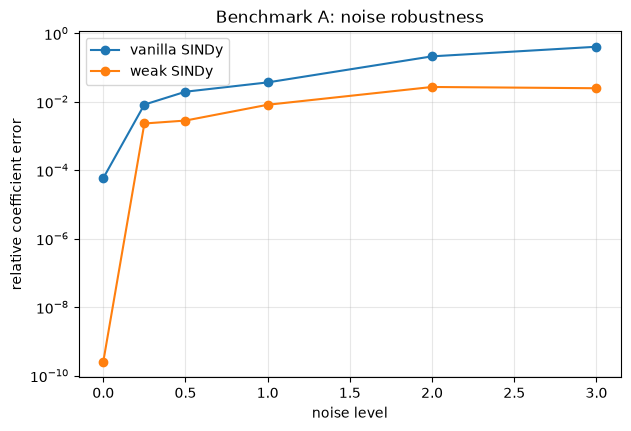

In [3]:
from sparse_demos import systems, metrics, plotting
import pysindy as ps

def lv_rel_error(model):
    names, C = model.get_feature_names(), model.coefficients()
    g = lambda n: C[:, names.index(n)] if n in names else np.zeros(C.shape[0])
    est = np.array([g("x")[0], g("x y")[0], g("y")[1], g("x y")[1]])
    return metrics.coef_l2_error(np.array([1.0, -0.1, -1.5, 0.075]), est)

noise_levels = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0]
errs = {"vanilla SINDy": [], "weak SINDy": []}
for nz in noise_levels:
    tt, XX = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01, noise_std=nz, seed=11)
    ddt = tt[1] - tt[0]
    v = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2), optimizer=ps.STLSQ(threshold=0.05))
    v.fit(XX, t=ddt, feature_names=["x", "y"])
    wl = ps.WeakPDELibrary(function_library=ps.PolynomialLibrary(degree=2, include_bias=True),
                           spatiotemporal_grid=tt, is_uniform=True, K=200)
    w = ps.SINDy(feature_library=wl, optimizer=ps.STLSQ(threshold=0.05))
    w.fit(XX, t=ddt, feature_names=["x", "y"])
    errs["vanilla SINDy"].append(lv_rel_error(v))
    errs["weak SINDy"].append(lv_rel_error(w))

plotting.plot_noise_sweep(noise_levels, errs, title="Benchmark A: noise robustness")
plt.show()

## Benchmark B — Michaelis–Menten (rational / DAE)

We ask each applicable method what it recovers for the substrate/product dynamics.

In [4]:
import pandas as pd
from daeFinder import solveMM, smooth_data, PolyFeatureMatrix, sequentialThLin

# --- data for the ODE-style methods (reduced rational substrate law) ---
t, Xr = systems.simulate_mm(t_span=(0, 8), dt=0.02, s0=2.0, vmax=1.0, km=0.5)
S = Xr[:, :1]; dt = t[1] - t[0]

# Vanilla SINDy: polynomial approximation (wrong form)
van = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3), optimizer=ps.STLSQ(threshold=0.01))
van.fit(S, t=dt, feature_names=["S"])

# SINDy-PI: implicit rational recovery
pde = ps.PDELibrary(function_library=ps.PolynomialLibrary(degree=2, include_bias=False),
                    derivative_order=1, temporal_grid=t, implicit_terms=True, include_bias=True)
pi = ps.SINDy(feature_library=pde,
              optimizer=ps.SINDyPI(reg_weight_lam=1e-4, regularizer="l1",
                                   tol=1e-10, max_iter=20000, normalize_columns=False))
pi.fit(S, t=dt, feature_names=["S"])

print("--- Vanilla SINDy (polynomial library) ---")
van.print()
print("\n--- SINDy-PI (implicit), read the (S) = ... row ---")
pi.print(precision=3)

Model  0


Model  1
Model  2
Model  3


Model  4
Model  5
--- Vanilla SINDy (polynomial library) ---
(S)' = -0.007 1 + -1.456 S +  1.044 S^2 + -0.262 S^3

--- SINDy-PI (implicit), read the (S) = ... row ---
(1) = -0.052 1 + -68022.725 S +  0.284 S^2 + -34015.366 S_t + -68020.881 SS_t
(S) = -0.500 S_t + -1.000 SS_t
(S^2) = -0.500 SS_t + -1.000 S^2S_t
(S_t) = -2.000 S + -2.000 SS_t
(SS_t) = -1.000 S + -0.500 S_t
(S^2S_t) = -1.000 S^2 + -0.500 SS_t


In [5]:
# --- SODAs on the full DAE (species [S],[E],[ES],[P]) ---
k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0})
IC = pd.Series({"S": 1.0, "P": 0.0, "E": 1.0})
tg = np.linspace(0, 4, 80); species = ["[S]", "[E]", "[ES]", "[P]"]
data = pd.DataFrame(solveMM(IC, k_rates, tg, "bench"), columns=species); data["[t]"] = tg
smooth = smooth_data(data, domain_var="[t]", derr_order=1, noise_perc=0, eval_points=tg)
lib = PolyFeatureMatrix(degree=2).fit_transform(data[species])

qssa = sequentialThLin(model_id="LR", coef_threshold=0.05, fit_intercept=False)
qssa.fit(X=lib[["[S] [E]"]], y=lib["[ES]"])
dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
dyn.fit(X=lib[["[S]", "[ES]", "[P]"]], y=smooth["d([P]) /dt"])
dterms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_) if abs(c) > 1e-3}

print("--- SODAs (DaeFinder) ---")
print("algebraic (QSSA): [ES] =", round(float(qssa.coef_[0]), 3), "* [S][E]   (true 0.5)")
print("dynamic        : d[P]/dt =", dterms, "  (true {'[ES]': 1.0})")

Sequential threshold converged in 0 iterations
Sequential threshold converged in 1 iterations
--- SODAs (DaeFinder) ---
algebraic (QSSA): [ES] = 0.5 * [S][E]   (true 0.5)
dynamic        : d[P]/dt = {'[ES]': 1.0}   (true {'[ES]': 1.0})


## Summary

| Method | Derivatives | Data type | Noise robustness | Rational / implicit | Algebraic (DAE) |
|---|---|---|---|---|---|
| **Vanilla SINDy** | pointwise (fragile) | ODE | low | ✗ | ✗ |
| **Weak SINDy** | integral / weak | ODE/PDE | **high** | ✗ | ✗ |
| **SINDy-PI** | implicit | ODE | medium | **✓** | partial |
| **SODAs** | smoothed + staged | **DAE** | medium–high | ✓ | **✓** |

**Conclusions**

- On clean polynomial ODEs, vanilla SINDy is the simplest and is exact.
- Under heavy noise, switch to the **weak form**.
- For **rational/implicit** dynamics, polynomial SINDy is structurally wrong; use
  **SINDy-PI**.
- For genuine **differential–algebraic** systems with conservation / quasi-steady-state
  structure, **SODAs** discovers the constraints and the dynamics together.

*There is no single best method — the right choice follows from your data (noise level)
and your model class (polynomial / rational / constrained).*